# Autocorrelación Espacial Local (*Local Spatial Autocorrelation*)

**Adaptado de:** Rey, Arribas-Bel & Wolf – *Geographic Data Science with Python*, Capítulo 7 (https://geographicdata.science/book/notebooks/07_local_autocorrelation.html).

# 1. De lo global a lo local

En la **clase 04** medimos la autocorrelación espacial **global** del voto Leave en el referéndum del Brexit. Con cinco estadísticos distintos — Join Counts, I de Moran, C de Geary y G de Getis-Ord — llegamos siempre a la misma conclusión: el voto Leave **no está distribuido al azar** en el territorio. Hay agrupamiento espacial, y es estadísticamente muy significativo.

Pero un indicador global es, por construcción, **un solo número para todo el mapa**. Nos dice *si* hay clustering, pero no *dónde* ocurre ni de qué tipo. Si el I de Moran global del voto Leave es 0.64, ese 0.64 es un promedio: resume simultáneamente los clusters Leave del este de Inglaterra, los clusters Remain de Escocia y Londres, y las áreas que rompen el patrón (como Liverpool). Todo eso queda comprimido en un número.

La **autocorrelación espacial local** rompe esa agregación. En lugar de un número global, calcula un estadístico **para cada observación**, lo que permite responder preguntas mucho más concretas:

- ¿Dónde están los **hot spots** (concentraciones de valores altos)?
- ¿Dónde están los **cold spots** (concentraciones de valores bajos)?
- ¿Hay **outliers espaciales** — áreas cuyo valor es muy distinto al de sus vecinos?
- ¿Qué proporción del mapa es estadísticamente distinguible del ruido aleatorio?

Los estadísticos locales se conocen como **LISAs** (*Local Indicators of Spatial Association*). En este notebook veremos los dos más utilizados: el **I de Moran local** ($I_i$) y el **G de Getis-Ord local** ($G_i$, $G_i^*$).

## Global vs. Local — resumen conceptual

| Aspecto | Estadísticos globales | Estadísticos locales (LISA) |
|---------|-----------------------|------------------------------|
| Número de valores | 1 para todo el mapa | 1 por observación ($n$ valores) |
| Pregunta que responden | ¿Hay clustering? | ¿Dónde y de qué tipo es el clustering? |
| Salida típica | Un estadístico + p-valor | Un mapa de categorías |
| Ejemplos | I de Moran, C de Geary, G de Getis-Ord | $I_i$, $G_i$, $G_i^*$ |

Propiedad matemática importante: **los indicadores locales se suman al global**. Para el I de Moran, por ejemplo,

$$I = \frac{1}{S_0} \sum_i I_i$$

donde $S_0$ es la suma de los pesos. Esto significa que el estadístico global no es algo separado del local — es literalmente **su promedio ponderado**.

# 2. Retomando el dataset Brexit

Para no perder continuidad con la clase anterior, seguimos trabajando sobre los resultados del referéndum del Brexit (2016). Los datos combinan los porcentajes de voto a nivel de autoridad local (Comisión Electoral) con las geometrías de los *Local Authority Districts* de la ONS. La variable de interés es `Pct_Leave`.

## 2.1 Importación de librerías

In [2]:
# Gráficos
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
import seaborn
import contextily

# Análisis espacial
import geopandas
import pandas as pd
import numpy as np
import esda
from esda.moran import Moran, Moran_Local
from esda.getisord import G_Local
from libpysal import weights
from numpy.random import seed

# Visualización específica de ESDA
import splot
from splot.esda import plot_moran, lisa_cluster, plot_local_autocorrelation

## 2.2 Carga y preparación de datos

In [3]:
# Resultados del referéndum
ref = pd.read_csv(
    "datos/external/brexit/brexit_vote.csv",
    index_col="Area_Code",
)

# Límites de los distritos de autoridad local
lads = geopandas.read_file(
    "datos/external/brexit/local_authority_districts.geojson"
).set_index("lad16cd")

# Combinar atributos + geometrías y reproyectar a Web Mercator
db = (
    geopandas.GeoDataFrame(
        lads.join(ref[["Pct_Leave"]]), crs=lads.crs
    )
    .to_crs(epsg=3857)[
        ["objectid", "lad16nm", "Pct_Leave", "geometry"]
    ]
    .dropna()
)
db.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 380 entries, E06000001 to W06000023
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   objectid   380 non-null    int64   
 1   lad16nm    380 non-null    object  
 2   Pct_Leave  380 non-null    float64 
 3   geometry   380 non-null    geometry
dtypes: float64(1), geometry(1), int64(1), object(1)
memory usage: 14.8+ KB


## 2.3 Matriz de pesos espaciales

Usamos la misma matriz de la clase 04: **k-vecinos más cercanos con $k=8$**, estandarizada por filas. Así cada fila suma 1 y el rezago espacial $W \cdot y$ es un promedio ponderado de los 8 vecinos de cada autoridad local.

In [4]:
w = weights.KNN.from_dataframe(db, k=8)
w.transform = "R"

## 2.4 Variable estandarizada y rezago espacial

Recordemos que todos los indicadores de Moran (global y local) se calculan sobre la variable **centrada en la media** — es decir, restamos el promedio nacional a cada valor:

$$z_i = y_i - \bar{y}$$

Así, $z_i > 0$ significa "voto Leave por encima del promedio" y $z_i < 0$ significa "por debajo". Este cambio de escala es lo que convierte al gráfico de Moran en un diagrama interpretable por **cuadrantes**.

In [7]:
# Variable estandarizada (centrada en la media)
db["Pct_Leave_std"] = db["Pct_Leave"] - db["Pct_Leave"].mean()

# Rezago espacial de la variable estandarizada
db["Pct_Leave_lag"] = weights.lag_spatial(
    w, db["Pct_Leave_std"]
)

db[["Pct_Leave", "Pct_Leave_std", "Pct_Leave_lag"]].head()

,Pct_Leave,Pct_Leave_std,Pct_Leave_lag
lad16cd,,,
E06000001,69.57,16.429237,7.780487
E06000002,65.48,12.339237,7.885487
E06000003,66.19,13.049237,7.510487
E06000004,61.73,8.589237,7.702987
E06000010,67.62,14.479237,7.326737


# 3. Del gráfico de Moran al mapa LISA

El **gráfico de Moran** (que ya vimos en la clase 04) es la puerta de entrada natural al análisis local. Su eje X es $z_i$ (el valor centrado) y su eje Y es $W z_i$ (el promedio estandarizado de los vecinos). Reconstruyámoslo para tener el punto de partida:

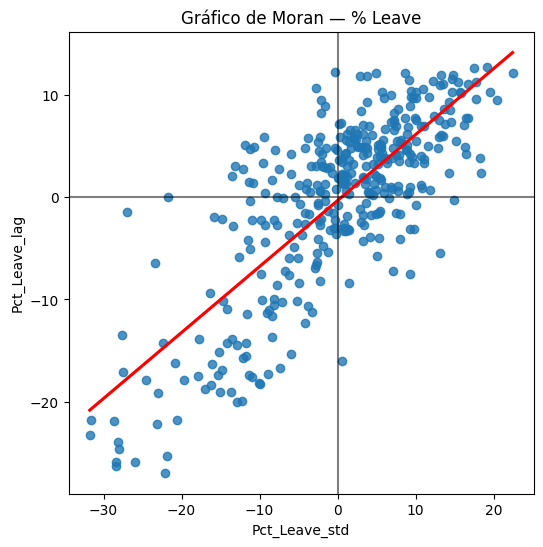

In [9]:
f, ax = plt.subplots(1, figsize=(6, 6))
seaborn.regplot(
    x="Pct_Leave_std",
    y="Pct_Leave_lag",
    ci=None,
    data=db,
    line_kws={"color": "r"},
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
ax.set_title("Gráfico de Moran — % Leave")
plt.show()

## 3.1 Los cuatro cuadrantes, traducidos a geografía

Las dos líneas (eje X=0, eje Y=0) dividen el gráfico en **cuatro cuadrantes**, y cada uno tiene una interpretación geográfica distinta:

| Código | Cuadrante | Valor propio ($z_i$) | Valor vecinos ($W z_i$) | Nombre | Interpretación |
|--------|-----------|----------------------|--------------------------|--------|----------------|
| **HH** (1) | Arriba-derecha | alto (+) | alto (+) | *hot spot* | Leave alto rodeado de Leave alto |
| **LL** (3) | Abajo-izquierda | bajo (−) | bajo (−) | *cold spot* | Leave bajo rodeado de Leave bajo |
| **LH** (2) | Arriba-izquierda | bajo (−) | alto (+) | *doughnut* | Isla Remain en región Leave |
| **HL** (4) | Abajo-derecha | alto (+) | bajo (−) | *diamond* | Isla Leave en región Remain |

Los dos primeros (HH y LL) indican **autocorrelación positiva**: la unidad y sus vecinos están del mismo lado de la media. Los dos últimos (LH y HL) son **outliers espaciales**: la unidad contradice a su vecindario — ejemplos clásicos son **Liverpool** (Remain en medio del norte de Inglaterra pro-Leave) o algunas zonas pesqueras escocesas que votaron Leave en una Escocia mayoritariamente Remain.

**Idea central:** si pintamos cada polígono del mapa según el cuadrante al que pertenece su punto en el gráfico de Moran, obtenemos un **mapa LISA**. Esa es, en esencia, toda la idea.

### Una advertencia importante sobre $I_i$

El valor numérico del I de Moran local, $I_i$, **no distingue HH de LL**: ambos son positivos (porque $z_i$ y $W z_i$ tienen el mismo signo, así que su producto es positivo). Tampoco distingue LH de HL: ambos dan $I_i$ negativo. Por eso la clasificación por cuadrante usa el **signo individual** de $z_i$ y de $W z_i$ — no el producto.

# 4. I de Moran local ($I_i$)

Formalmente, el I de Moran local para la observación $i$ se define como:

$$I_i = \frac{z_i}{m_2} \sum_j w_{ij}\, z_j \qquad \text{con} \qquad m_2 = \frac{\sum_i z_i^2}{n}$$

Es decir: toma el valor centrado de la unidad $i$, lo multiplica por el promedio (ponderado) de los valores centrados de sus vecinos, y lo escala por la varianza total de la variable ($m_2$).

Interpretación directa:

- Si $z_i > 0$ y sus vecinos también ($\sum w_{ij} z_j > 0$) → $I_i > 0$ → **HH**.
- Si $z_i < 0$ y sus vecinos también → $I_i > 0$ → **LL**.
- Si $z_i > 0$ pero sus vecinos tienen valores bajos → $I_i < 0$ → **HL**.
- Si $z_i < 0$ pero sus vecinos tienen valores altos → $I_i < 0$ → **LH**.

Y como anticipamos, se cumple la descomposición:

$$I = \frac{1}{S_0} \sum_i I_i$$

Es decir, el I de Moran global (0.64 en nuestros datos) es exactamente el promedio de los 380 $I_i$ locales (ponderado por $S_0$, la suma de los pesos).

## 4.1 Cálculo con `esda`

La librería `esda` calcula $I_i$, su p-valor por permutaciones y la clasificación por cuadrante en una sola línea:

In [10]:
seed(1234)  # Reproducibilidad del test de permutaciones
lisa = Moran_Local(db["Pct_Leave"], w)

### Atributos del objeto `lisa`

`Moran_Local` devuelve un objeto con varios atributos; los más importantes son:

| Atributo | Qué contiene |
|----------|--------------|
| `lisa.Is` | Array de tamaño $n$ con el valor $I_i$ de cada observación |
| `lisa.q` | Array de tamaño $n$ con el cuadrante: 1=HH, 2=LH, 3=LL, 4=HL |
| `lisa.p_sim` | Pseudo p-valor por permutaciones para cada observación |
| `lisa.z_sim` | z-score estandarizado de $I_i$ bajo la distribución de referencia |
| `lisa.EI_sim` | Valor esperado de $I_i$ bajo aleatoriedad (promedio de las permutaciones) |

Veamos las primeras filas:

In [11]:
resumen = pd.DataFrame({
    "Pct_Leave": db["Pct_Leave"].values,
    "I_i": lisa.Is,
    "cuadrante": lisa.q,
    "p_sim": lisa.p_sim,
}, index=db.index)
resumen.head()

,Pct_Leave,I_i,cuadrante,p_sim
lad16cd,,,,
E06000001,69.57,1.178303,1,0.006
E06000002,65.48,0.896912,1,0.006
E06000003,66.19,0.903413,1,0.009
E06000004,61.73,0.609883,1,0.008
E06000010,67.62,0.977888,1,0.014


# 5. Significancia estadística mediante permutaciones

La lógica es idéntica a la que usamos para el I de Moran global, el C de Geary o el G de Getis-Ord en la clase 04. Para cada observación:

1. Se fija la geometría (los polígonos y la matriz $W$ no cambian).
2. Se **permutan** los 380 valores de `Pct_Leave` entre las áreas — 999 veces.
3. En cada permutación, se recalcula $I_i$ para esa observación.
4. Se construye una **distribución de referencia** bajo aleatoriedad.
5. El **pseudo p-valor** es la proporción de permutaciones en las que $I_i$    resultó ser tan o más extremo que el valor observado.

Con 999 permutaciones el mínimo detectable es $p = (0 + 1)/(999 + 1) = 0.001$. Usaremos el umbral clásico de $p < 0.05$ para declarar significativo un cluster.

## 5.1 Construcción del vector `spots`

El truco estándar para construir el mapa LISA es multiplicar el cuadrante por la significancia: las áreas no significativas quedan con valor 0, y las significativas conservan su código de cuadrante (1 a 4).

In [12]:
# Máscara de significancia al 5%
sig = (lisa.p_sim < 0.05).astype(int)
db["sig"] = sig

db

,objectid,lad16nm,Pct_Leave,geometry,Pct_Leave_std,Pct_Leave_lag_std,Pct_Leave_lag,sig
lad16cd,,,,,,,,
E06000001,1,Hartlepool,69.57,"MULTIPOLYGON (((-141402.215 7309092.065, -1537...",16.429237,7.780487,7.780487,1
E06000002,2,Middlesbrough,65.48,"MULTIPOLYGON (((-136924.099 7281563.141, -1426...",12.339237,7.885487,7.885487,1
E06000003,3,Redcar and Cleveland,66.19,"MULTIPOLYGON (((-126588.382 7293641.928, -1260...",13.049237,7.510487,7.510487,1
E06000004,4,Stockton-on-Tees,61.73,"MULTIPOLYGON (((-146690.634 7293316.144, -1537...",8.589237,7.702987,7.702987,1
E06000010,10,"Kingston upon Hull, City of",67.62,"MULTIPOLYGON (((-35191.009 7134866.244, -39368...",14.479237,7.326737,7.326737,1
...,...,...,...,...,...,...,...,...
W06000018,385,Caerphilly,57.63,"POLYGON ((-367500.093 6763858.294, -368477.326...",4.489237,0.202987,0.202987,0
W06000019,386,Blaenau Gwent,62.03,"POLYGON ((-361591.484 6766770.434, -368477.326...",8.889237,0.324237,0.324237,0
W06000021,388,Monmouthshire,49.56,"MULTIPOLYGON (((-339763.135 6795234.133, -3414...",-3.580763,0.446737,0.446737,0


In [13]:
# 0 = no significativo, 1=HH, 2=LH, 3=LL, 4=HL
db["spots"] = lisa.q * sig

# Etiquetas legibles
spots_labels = {
    0: "No significativo",
    1: "HH (hot spot)",
    2: "LH (doughnut)",
    3: "LL (cold spot)",
    4: "HL (diamond)",
}
db["labels"] = db["spots"].map(spots_labels)
db["labels"].value_counts()

labels
No significativo    226
HH (hot spot)        74
LL (cold spot)       70
LH (doughnut)         6
HL (diamond)          4
Name: count, dtype: int64

# 6. Mapa de clusters LISA

Para el mapa usamos la **paleta estándar** de los análisis LISA, que es la misma en PySAL, GeoDa y la literatura:

| Categoría | Color | Hex |
|-----------|-------|-----|
| HH (hot spot) | rojo fuerte | `#d7191c` |
| LL (cold spot) | azul fuerte | `#2c7bb6` |
| LH (doughnut) | celeste claro | `#abd9e9` |
| HL (diamond) | naranja | `#fdae61` |
| No significativo | gris claro | `#dddddd` |

Los dos "fuertes" (rojo y azul) corresponden a la autocorrelación positiva (clusters puros), y los dos "intermedios" (celeste y naranja) a los outliers. Es una convención — se respeta para que los mapas LISA sean legibles entre distintas publicaciones sin leyenda.

## 6.1 Versión manual (con `matplotlib`)

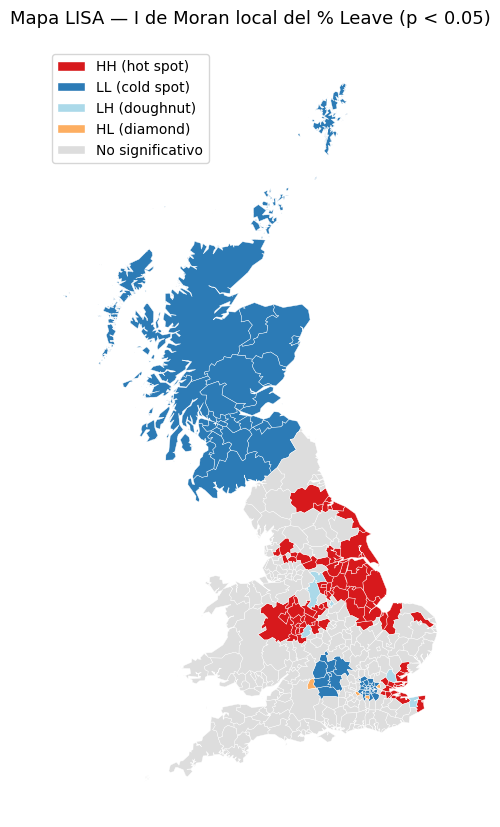

In [14]:
colores_lisa = {
    "HH (hot spot)":   "#d7191c",
    "LL (cold spot)":  "#2c7bb6",
    "LH (doughnut)":   "#abd9e9",
    "HL (diamond)":    "#fdae61",
    "No significativo": "#dddddd",
}

f, ax = plt.subplots(1, figsize=(8, 10))
for cat, color in colores_lisa.items():
    sub = db[db["labels"] == cat]
    if len(sub):
        sub.plot(ax=ax, color=color, edgecolor="white", linewidth=0.3)

handles = [Patch(facecolor=c, edgecolor="white", label=l)
           for l, c in colores_lisa.items()]
ax.legend(handles=handles, loc="upper left", frameon=True, fontsize=10)
ax.set_title("Mapa LISA — I de Moran local del % Leave (p < 0.05)", fontsize=13)
ax.set_axis_off()
plt.show()

## 6.2 Versión con `splot`

La librería `splot` incluye una función dedicada, `lisa_cluster`, que hace exactamente lo mismo en una sola línea. Es la forma más rápida y conveniente en la práctica:

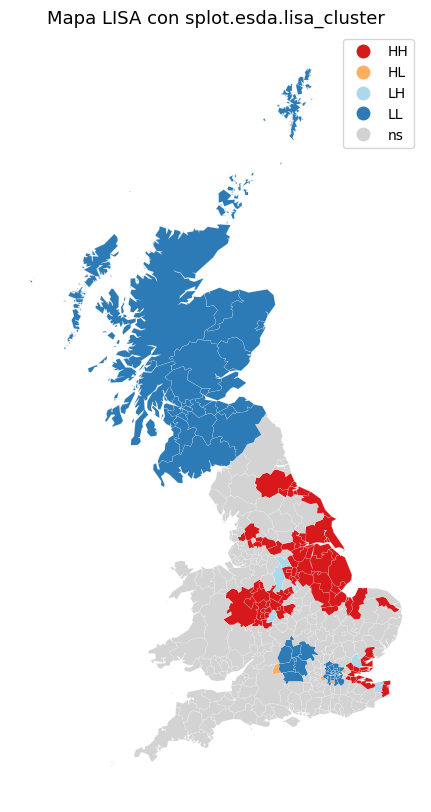

In [15]:
f, ax = plt.subplots(1, figsize=(8, 10))
lisa_cluster(lisa, db, p=0.05, ax=ax)
ax.set_title("Mapa LISA con splot.esda.lisa_cluster", fontsize=13)
ax.set_axis_off()
plt.show()

`splot` también ofrece una vista combinada muy útil — gráfico de Moran + mapa de significancia + mapa LISA lado a lado — con `plot_local_autocorrelation`:

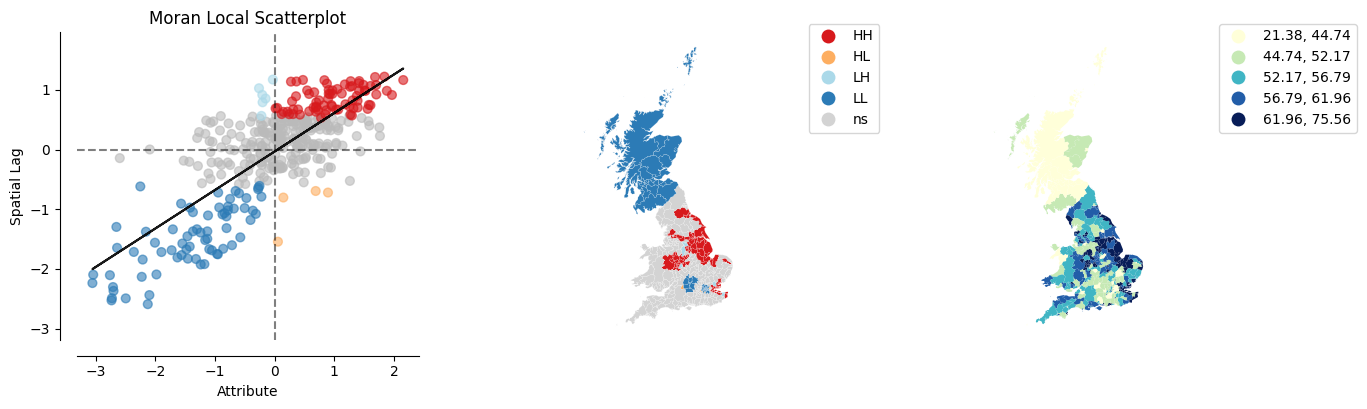

In [16]:
fig = plot_local_autocorrelation(lisa, db, "Pct_Leave", p=0.05)
plt.show()

# 7. Lectura del mapa

El mapa LISA revela una estructura geográfica muy clara del voto Leave:

- **HH (rojo) — corazón Leave:** una franja continua de autoridades locales   en los *Midlands*, Lincolnshire y la costa este de Inglaterra. Son las   zonas donde el voto Leave fue alto Y sus vecinos también tuvieron voto   Leave alto — no es un fenómeno puntual, es una **región** pro-Leave.

- **LL (azul) — corazón Remain:** concentrado en Londres (y su cinturón),   en las grandes ciudades universitarias (Oxford, Cambridge, Bristol,   Manchester) y en Escocia. Áreas de voto Remain rodeadas de áreas de voto   Remain.

- **LH (celeste) — *doughnuts*:** áreas Remain rodeadas por Leave. **Liverpool**   es el caso emblemático: una ciudad fuertemente Remain en medio del noroeste   de Inglaterra, que votó mayoritariamente Leave.

- **HL (naranja) — *diamonds*:** áreas Leave rodeadas por Remain. Pocos   casos; suelen ser enclaves rurales dentro de regiones urbanas Remain.

- **Gris — no significativo:** aproximadamente 60% de las áreas. No podemos   rechazar la hipótesis de que su $I_i$ sea producto del azar. Esto **no**   quiere decir que no exista una tendencia — quiere decir que los datos   disponibles no son lo suficientemente informativos como para afirmarla   con confianza estadística.

In [12]:
# Distribución proporcional de cada categoría
prop = db["labels"].value_counts(normalize=True).mul(100).round(1)
prop.to_frame("porcentaje")

,porcentaje
labels,
No significativo,59.5
HH (hot spot),19.5
LL (cold spot),18.4
LH (doughnut),1.6
HL (diamond),1.1


Algo a retener: solo un subconjunto del territorio muestra un patrón estadísticamente significativo. Lo habitual en un análisis LISA es que entre un **30% y 50%** de las áreas queden clasificadas como clusters — y que los outliers (LH + HL) sean una fracción pequeña (típicamente menos del 10%). No hay que forzar interpretaciones sobre las zonas grises: si el estadístico dice "no se distingue del azar", eso es lo que hay.

## Nota técnica — `Pct_Leave` es una tasa

La variable que analizamos (`Pct_Leave`) es una **proporción**: votos Leave dividido votos totales. Cuando la autocorrelación espacial se calcula sobre tasas, hay que ser cuidadoso porque el **denominador** (el tamaño del padrón electoral) puede variar mucho entre áreas — y esa variación introduce ruido que no es geográfico sino demográfico. Una autoridad local con padrón pequeño tiene una tasa mucho más volátil que una con padrón grande.

Para corregir este problema, `esda` ofrece las versiones *rate*:

- `esda.moran.Moran_Rate` — versión global corregida.
- `esda.moran.Moran_Local_Rate` — versión local corregida.

Estas funciones aceptan por separado el **numerador** (votos Leave) y el **denominador** (votos totales) y aplican un suavizado empírico de Bayes para compensar la heterogeneidad de las tasas. En este notebook trabajamos con la versión sin corregir por simplicidad, pero en un análisis de producción conviene comparar ambos resultados.

# 8. Getis-Ord local: $G_i$ y $G_i^*$

En la clase 04 vimos brevemente $G_i^*$ como la versión local del G de Getis-Ord. Aquí profundizamos y comparamos las dos variantes que existen:

$$G_i = \frac{\sum_{j \neq i} w_{ij}\, y_j}{\sum_{j \neq i} y_j}
\qquad\qquad
G_i^* = \frac{\sum_j w_{ij}\, y_j}{\sum_j y_j}$$

La diferencia está en si se **incluye o no el sitio focal $i$** en el numerador y denominador:

- **$G_i$** (sin estrella): mira solo a los **vecinos** de $i$. Ignora el   valor de $i$ misma. Útil cuando queremos saber si el *entorno* de $i$   concentra valores altos, independientemente de lo que pase en $i$.
- **$G_i^*$** (con estrella): incluye a $i$ en su propio vecindario.   Captura mejor la idea de *hot spot* en sentido pleno: "$i$ es un punto   caliente porque ella Y sus vecinos tienen valores altos".

Ambos se estandarizan a z-score y se testean por permutaciones, igual que $I_i$.

**Diferencia conceptual respecto a LISA:** Getis-Ord no distingue outliers. Solo dice "alta concentración" (z > 0) o "baja concentración" (z < 0). No hay equivalente a LH o HL. Por eso es el estadístico preferido para análisis de *hot spots* puros (focos de contagio, zonas de crimen, clusters de pobreza), pero pierde la información de outliers espaciales que sí captura el I de Moran local.

In [17]:
seed(1234)

# Gi  (excluye el sitio focal)
go_i = G_Local(db["Pct_Leave"], w, star=False)

# Gi* (incluye el sitio focal)
go_i_star = G_Local(db["Pct_Leave"], w, star=True)

db["Gi_z"] = go_i.Zs
db["Gi_p"] = go_i.p_sim
db["Gistar_z"] = go_i_star.Zs
db["Gistar_p"] = go_i_star.p_sim

/Users/calipsotornasol/Documents/geodata/.venv/lib/python3.11/site-packages/esda/getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)


## 8.1 Comparando $G_i$ y $G_i^*$

Cuando el valor focal $y_i$ es alto, incluirlo (como hace $G_i^*$) **refuerza** el puntaje; cuando es bajo, lo **atenúa**. Veamos la diferencia en los z-scores para las autoridades con mayor voto Leave:

In [19]:
comparacion = db[[
    "lad16nm", "Pct_Leave", "Gi_z", "Gistar_z"
]].copy()
comparacion["diff_z"] = comparacion["Gistar_z"] - comparacion["Gi_z"]

# 10 áreas con mayor voto Leave
comparacion.sort_values("Pct_Leave", ascending=False).head(10)

,lad16nm,Pct_Leave,Gi_z,Gistar_z,diff_z
lad16cd,,,,,
E07000136,Boston,75.56,1.176117,1.274804,0.098687
E07000140,South Holland,73.59,0.923362,1.031472,0.108110
E07000069,Castle Point,72.70,0.992545,1.083813,0.091269
E06000034,Thurrock,72.28,1.230089,1.290079,0.059991
E07000145,Great Yarmouth,71.50,0.233081,0.398573,0.165492
E07000010,Fenland,71.39,0.375717,0.523871,0.148154
E07000174,Mansfield,70.86,0.929557,1.009467,0.079911
E07000033,Bolsover,70.83,1.088080,1.149720,0.061641
E07000137,East Lindsey,70.65,1.222868,1.267434,0.044566


In [20]:
# 10 áreas con menor voto Leave (Remain fuerte)
comparacion.sort_values("Pct_Leave").head(10)

,lad16nm,Pct_Leave,Gi_z,Gistar_z,diff_z
lad16cd,,,,,
E09000022,Lambeth,21.38,-2.270492,-2.327967,-0.057475
E09000012,Hackney,21.52,-2.128531,-2.201921,-0.073390
E09000014,Haringey,24.43,-2.131133,-2.177887,-0.046754
E09000001,City of London,24.71,-2.556580,-2.550256,0.006324
E09000019,Islington,24.78,-2.520316,-2.517677,0.002640
E09000032,Wandsworth,24.97,-2.331116,-2.349224,-0.018108
E09000007,Camden,25.06,-2.395779,-2.405410,-0.009631
S12000036,City of Edinburgh,25.56,-1.314242,-1.447249,-0.133007
S12000011,East Renfrewshire,25.68,-1.667201,-1.757343,-0.090142


Se observa el patrón esperado: en las áreas de voto Leave extremo, $G_i^*$ es sistemáticamente **más alto** que $G_i$ (la diferencia en `diff_z` es positiva). En las áreas de voto Remain extremo, $G_i^*$ es **más bajo**. La inclusión del sitio focal amplifica la señal.

En la práctica, para identificar *hot spots* se usa **casi siempre** $G_i^*$ — es la opción por defecto en GeoDa, ArcGIS y la mayoría de la literatura aplicada.

## 8.2 Mapa de hot spots $G_i^*$

Clasificamos cada área como hot spot, cold spot o no significativa usando el mismo criterio del notebook 04 ($p < 0.05$ + signo del z-score):

In [21]:
def clasificar_gi(z, p):
    if p >= 0.05:
        return "No significativo"
    return "Hot spot" if z > 0 else "Cold spot"

db["Gistar_cat"] = [
    clasificar_gi(z, p)
    for z, p in zip(db["Gistar_z"], db["Gistar_p"])
]
db["Gistar_cat"].value_counts()

Gistar_cat
No significativo    224
Hot spot             83
Cold spot            73
Name: count, dtype: int64

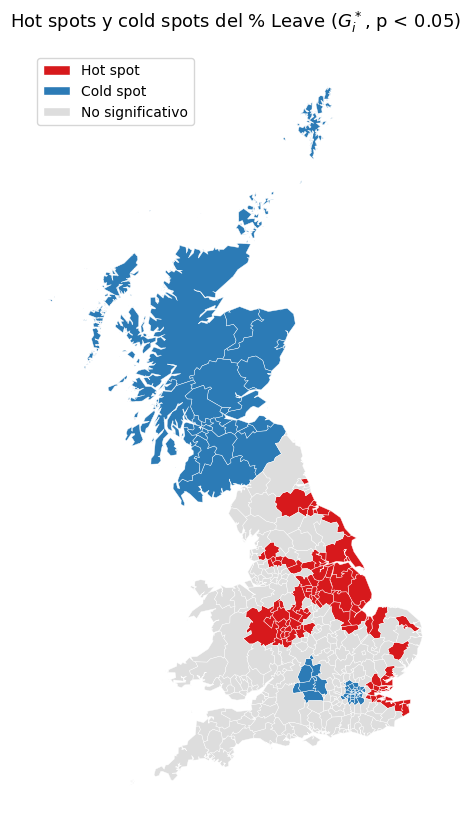

In [22]:
colores_gi = {
    "Hot spot":         "#d7191c",
    "Cold spot":        "#2c7bb6",
    "No significativo": "#dddddd",
}

f, ax = plt.subplots(1, figsize=(8, 10))
for cat, color in colores_gi.items():
    sub = db[db["Gistar_cat"] == cat]
    if len(sub):
        sub.plot(ax=ax, color=color, edgecolor="white", linewidth=0.3)

handles = [Patch(facecolor=c, edgecolor="white", label=l)
           for l, c in colores_gi.items()]
ax.legend(handles=handles, loc="upper left", frameon=True, fontsize=10)
ax.set_title("Hot spots y cold spots del % Leave ($G_i^*$, p < 0.05)",
             fontsize=13)
ax.set_axis_off()
plt.show()

Compare este mapa con el mapa LISA de la Sección 6. Verá que los **hot spots y cold spots coinciden aproximadamente** con las regiones HH y LL, pero las zonas LH/HL (los outliers espaciales) se diluyen: algunas aparecen como "no significativo" en el mapa $G_i^*$, porque para Getis-Ord solo cuenta la **dirección** del clustering, no si hay outliers.

Esa es la diferencia operativa clave entre los dos estadísticos locales.

# 9. Síntesis comparativa

| Estadístico | Escala | Qué detecta | Distingue outliers (LH/HL) | Función `esda` |
|-------------|--------|-------------|-----------------------------|----------------|
| I de Moran  | Global | Clustering general | — | `Moran` |
| C de Geary  | Global | Diferencias entre vecinos | — | `Geary` |
| G de Getis-Ord | Global | Concentración alta/baja | — | `G` |
| **$I_i$** (Moran local) | **Local** | **HH / LL / LH / HL por área** | **Sí** | `Moran_Local` |
| **$G_i$, $G_i^*$** | **Local** | **Hot / cold spots por área** | **No** | `G_Local` |

Flujo de trabajo recomendado:

1. **Siempre empezar por el global.** ¿Hay algo que explicar? Si el I de    Moran global es ~0 y no significativo, los LISA tampoco darán mucho.
2. **I de Moran local** para obtener el panorama completo: clusters +    outliers, con las cuatro categorías.
3. **$G_i^*$** si el interés está en localizar hot spots "puros" sin    preocuparse por outliers (aplicaciones epidemiológicas, criminología,    seguridad pública, salud).
4. **Siempre reportar** el mapa LISA junto con el conteo de áreas    significativas y no significativas — no solo las zonas de color.

# 10. Bonus: LISA sobre superficies (raster)

Hasta aquí trabajamos con una **geo-tabla**: polígonos con atributos. Pero muchos fenómenos se miden sobre una **grilla continua** — densidad de población, temperatura, radiación, NDVI, contaminación. La pregunta natural es: **¿se puede hacer LISA sobre un raster?**

Técnicamente sí, pero con dos desafíos importantes:

1. **Escala computacional.** Un raster moderado puede tener millones de    píxeles. Construir la matriz $W$ completa es inviable en memoria densa;    hay que trabajar con representaciones *sparse*.
2. **Manejo de `nodata`.** Los rásters suelen tener píxeles sin dato (mar,    nubes, bordes); hay que excluirlos de $W$ y de los cálculos.

El capítulo 7 del libro lo plantea de forma explícita: *"La aplicación de LISA sobre superficies es un área activa de desarrollo; las herramientas todavía son experimentales y algo rudimentarias comparadas con el ecosistema para geo-tablas."*

El flujo conceptual es el que muestran las siguientes celdas (marcadas como **demostrativas** porque dependen de un raster GHSL que no está en el repositorio del curso). No ejecutarlas tal cual — son para que veamos los pasos:

In [23]:
# ======================================================================
# CELDA DEMOSTRATIVA — requiere el raster de población GHSL de São Paulo.
# No se ejecuta por defecto (el archivo .tif no está en datos/).
# ======================================================================
#
# import rioxarray
# import xarray
# from libpysal.weights import raster, WSP, WSP2W, w_subset, Queen
#
# # 1. Cargar el raster de densidad poblacional
# pop = rioxarray.open_rasterio("datos/external/ghsl/ghsl_sao_paulo.tif")
#
# # 2. Construir W sparse desde el raster (Queen contiguity entre píxeles)
# w_surface_sp = Queen.from_xarray(pop)
#
# # 3. Convertir a WSP2W completo, preservando el índice del raster
# w_surface_all = WSP2W(
#     WSP(
#         w_surface_sp.sparse.astype(float),
#         id_order=w_surface_sp.index.tolist(),
#     )
# )
# w_surface_all.index = w_surface_sp.index

In [ ]:
# ======================================================================
# CELDA DEMOSTRATIVA (continuación)
# ======================================================================
#
# # 4. Pasar el raster a Series y filtrar NoData
# pop_values = pop.to_series()
# pop_values = pop_values[pop_values != pop.rio.nodata]
#
# # 5. Submuestrear W para que coincida con los píxeles con dato
# w_surface = w_subset(w_surface_all, pop_values.index)
# w_surface.index = pop_values.index
#
# # 6. Calcular LISA en paralelo (n_jobs=-1 usa todos los cores disponibles)
# pop_lisa = Moran_Local(
#     pop_values.astype(float), w_surface, n_jobs=-1
# )
#
# # 7. Clasificar por cuadrante × significancia (idéntico al caso vectorial)
# sig_pop = pd.Series(
#     pop_lisa.q * (pop_lisa.p_sim < 0.01),
#     index=pop_values.index,
# )
#
# # 8. Reconstruir un DataArray raster con los resultados para mapearlo
# lisa_da = raster.w2da(
#     sig_pop, w_surface,
#     attrs={"nodatavals": [pop.rio.nodata]},
# ).rio.write_crs(pop.rio.crs)
#
# # 9. Colormap discreto compatible con la paleta LISA estándar
# lc = {
#     "ns": "lightgrey",
#     "HH": "#d7191c",
#     "LH": "#abd9e9",
#     "LL": "#2c7bb6",
#     "HL": "#fdae61",
# }
# lisa_cmap = ListedColormap(
#     [lc["ns"], lc["HH"], lc["LH"], lc["LL"], lc["HL"]]
# )
# lisa_da.plot(cmap=lisa_cmap)

Lo importante aquí no es el código per se — es que el **marco conceptual no cambia**:

- La variable ahora es el valor del píxel.
- Los "vecinos" son los píxeles adyacentes (Queen = 8 vecinos, Rook = 4 vecinos).
- Los estadísticos ($I_i$, $G_i^*$) se calculan con las mismas fórmulas.
- La significancia se evalúa con permutaciones (suele usarse $p < 0.01$ en   vez de $0.05$, porque con millones de píxeles el riesgo de falsos positivos   por múltiples comparaciones es muy alto).

Para un curso introductorio, alcanza con saber que **esta extensión existe**; los detalles se cubren al pasar a Teledetección o a análisis espacial avanzado.

# 11. Cierre

Lo que aprendimos en esta clase:

1. **Los LISA descomponen el estadístico global en $n$ valores locales**,    uno por observación. Matemáticamente: $I = \frac{1}{S_0} \sum_i I_i$.
2. **El I de Moran local identifica cuatro tipos de patrón espacial**: HH,    LL, LH y HL. Los dos primeros son clusters; los dos últimos son outliers.
3. **La significancia se evalúa con permutaciones** (999 mapas aleatorios),    idéntico al caso global.
4. **El mapa LISA combina cuadrante y significancia**, coloreando solo las    áreas donde $p < 0.05$.
5. **Getis-Ord local ($G_i$, $G_i^*$) es complementario**: detecta hot y    cold spots pero no outliers espaciales. $G_i^*$ incluye el sitio focal    y es la versión más usada en la práctica.
6. **Para tasas**, existen versiones corregidas (`Moran_Local_Rate`).
7. **Para rásters**, la extensión existe pero aún es experimental.

En la **actividad 05** (`actividades/05_autocorrelacion_elecciones_chile.ipynb`) aplicaremos estos mismos estadísticos a los resultados de la segunda vuelta presidencial chilena de 2025 en la Región Metropolitana, para identificar los hot/cold spots de cada candidatura y los outliers espaciales del voto.

## Referencias

- Anselin, L. (1995). Local Indicators of Spatial Association — LISA.   *Geographical Analysis*, 27(2), 93–115.
- Getis, A., & Ord, J. K. (1992). The Analysis of Spatial Association by   Use of Distance Statistics. *Geographical Analysis*, 24(3), 189–206.
- Fotheringham, A. S. (1997). Trends in quantitative methods I: stressing   the local. *Progress in Human Geography*, 21(1), 88–96.
- Nelson, T. A., & Boots, B. (2008). Detecting spatial hot spots in   landscape ecology. *Ecography*, 31(5), 556–566.
- Rey, S. J., Arribas-Bel, D., & Wolf, L. J. (2023). *Geographic Data   Science with Python*, Capítulo 7   (https://geographicdata.science/book/notebooks/07_local_autocorrelation.html).